# Simple Linear Regression — Food Delivery Time
### Same story as the board: dots -> line -> w, b -> predictions -> error -> best fit line

**Dataset:** `delivery_time_dataset.csv` (provided separately) — 5,000 rows, 2 columns: `distance_km` and `delivery_time_min`. Add it as a Kaggle input (or upload directly if running elsewhere).

Today's formula: **ŷ = w·x + b** — x = distance, w = weight, b = bias, ŷ = predicted delivery time.

In [1]:
import os
dataset_paths = []
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        full_path = os.path.join(dirname, filename)
        print(full_path)
        if filename.endswith('.csv'):
            dataset_paths.append(full_path)
# If nothing printed: click 'Add Input' and attach 'delivery_time_dataset.csv' first
# (or, if running outside Kaggle, just set: dataset_paths = ['delivery_time_dataset.csv'])

/kaggle/input/datasets/gangabhavanidasam/delivery-time-data/delivery_time_dataset.xlsx
/kaggle/input/datasets/gangabhavanidasam/delivery-time-data/delivery_time_dataset.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
sns.set_style('whitegrid')


## 1. Load the data

In [3]:
assert len(dataset_paths) > 0, "No CSV found under /kaggle/input - click 'Add Input' and attach delivery_time_dataset.csv first."
df = pd.read_csv(dataset_paths[0])
df.head()

,distance_km,delivery_time_min
0,6.47,28.7
1,4.44,25.8
2,4.18,27.1
3,4.18,27.4
4,11.34,48.4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   distance_km        5000 non-null   float64
 1   delivery_time_min  5000 non-null   float64
dtypes: float64(2)
memory usage: 78.3 KB


## 2. Data preprocessing — step by step

Even a clean dataset gets the same checks every time, so this becomes a habit.

**Preprocessing step 1 — check for missing values.**

In [5]:
df.isnull().sum()

distance_km          0
delivery_time_min    0
dtype: int64

**Preprocessing step 2 — check for duplicate rows.**

In [6]:
print('Duplicate rows:', df.duplicated().sum())
df = df.drop_duplicates()
print('Shape after removing duplicates:', df.shape)

Duplicate rows: 77
Shape after removing duplicates: (4923, 2)


**Preprocessing step 3 — sanity-check the value ranges.** No negative distances, no impossible delivery times.

In [7]:
df.describe()

,distance_km,delivery_time_min
count,4923.000000,4923.000000
mean,5.549911,33.101605
std,3.135704,12.721103
min,0.580000,5.000000
25%,3.240000,23.900000
50%,4.900000,31.100000
75%,7.175000,40.300000
max,20.000000,92.300000


In [8]:
# Keep only rows with realistic values (this dataset is already clean, but we always check)
df_clean = df[(df['distance_km'] > 0) & (df['delivery_time_min'] > 0)].copy()
print('Rows remaining after sanity check:', df_clean.shape[0])

Rows remaining after sanity check: 4923


## 3. See the pattern — data as dots (same as the board)

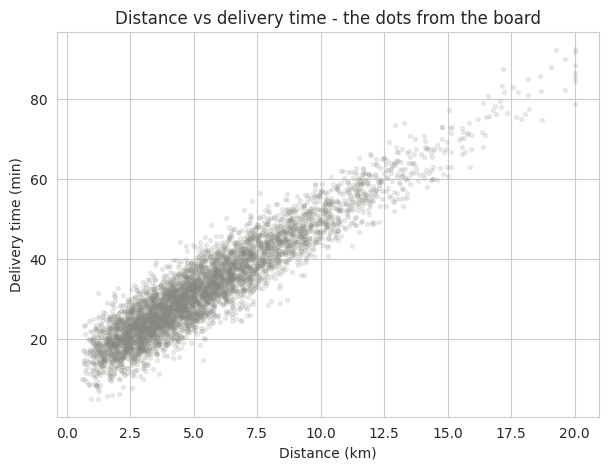

Correlation: 0.9359733332970112


In [9]:
plt.figure(figsize=(7,5))
plt.scatter(df_clean['distance_km'], df_clean['delivery_time_min'], alpha=0.15, s=8, color='#888780')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery time (min)')
plt.title('Distance vs delivery time - the dots from the board')
plt.show()

print('Correlation:', df_clean['distance_km'].corr(df_clean['delivery_time_min']))

## 4. Train / test split

We hold back part of the data (the test set) that the model never sees while learning, so we can honestly check how it performs on deliveries it hasn't encountered before.

```
Full dataset
     |
  -----------
  |         |
Training   Test
(~80%)    (~20%)
  |
model learns w, b
from this part ONLY
```

In [10]:
X = df_clean[['distance_km']].values   # double brackets keep this 2D - sklearn requires a 2D feature matrix
y = df_clean['delivery_time_min'].values

# test_size=0.2 -> 80% train, 20% test. random_state fixes the shuffle so results are reproducible.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training rows:', X_train.shape[0], '(model learns w, b from these)')
print('Test rows:', X_test.shape[0], '(used only to check performance afterward)')

Training rows: 3938 (model learns w, b from these)
Test rows: 985 (used only to check performance afterward)


## 5. Before training: w and b are unknown

Right now, nothing has been learned yet. `LinearRegression()` just creates an empty model.

In [11]:
model = LinearRegression()
print('Model created. w and b are not learned yet - training happens on the next line.')

Model created. w and b are not learned yet - training happens on the next line.


## 6. Training — `.fit()` finds the best w and b

This is the ONE line where everything from the board (best fit line, minimizing squared error) happens. scikit-learn solves for the exact best w and b directly (a method called least squares) rather than taking iterative small steps — but the goal is identical: minimize the total squared error across the training rows.

In [12]:
model.fit(X_train, y_train)   # learns from TRAINING data only

w = model.coef_[0]      # the learned weight (slope)
b = model.intercept_    # the learned bias (intercept)
print(f'Learned formula: delivery_time = {w:.3f} * distance + {b:.3f}')
print(f'\nInterpretation: each extra km adds about {w:.1f} minutes to the predicted delivery time.')

Learned formula: delivery_time = 3.792 * distance + 12.086

Interpretation: each extra km adds about 3.8 minutes to the predicted delivery time.


## 7. See the best fit line drawn over the dots

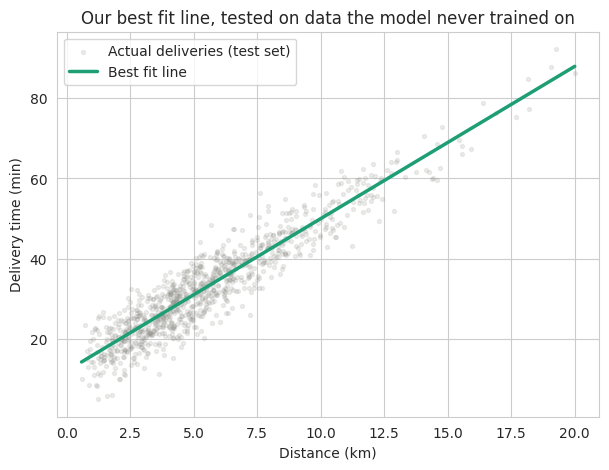

In [13]:
y_pred_test = model.predict(X_test)   # apply the learned line to the TEST distances (never seen during training)

plt.figure(figsize=(7,5))
plt.scatter(X_test, y_test, alpha=0.15, s=8, color='#888780', label='Actual deliveries (test set)')
sort_idx = X_test.flatten().argsort()
plt.plot(X_test.flatten()[sort_idx], y_pred_test[sort_idx], color='#1D9E75', linewidth=2.5, label='Best fit line')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery time (min)')
plt.title('Our best fit line, tested on data the model never trained on')
plt.legend()
plt.show()

## 8. Low x vs high x — watch the prediction move

In [14]:
for test_distance in [1, 3, 5, 8, 12]:
    predicted_time = model.predict([[test_distance]])[0]   # predict() expects a 2D input, so [[value]]
    print(f'Distance = {test_distance} km  ->  Predicted time = {predicted_time:.1f} min')

Distance = 1 km  ->  Predicted time = 15.9 min
Distance = 3 km  ->  Predicted time = 23.5 min
Distance = 5 km  ->  Predicted time = 31.0 min
Distance = 8 km  ->  Predicted time = 42.4 min
Distance = 12 km  ->  Predicted time = 57.6 min


## 9. Metrics — measured on the TEST set only

This is the honest check: how good are the predictions on deliveries the model never trained on?

In [15]:
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print(f'MAE:  {mae:.2f} minutes  -> on average, predictions are off by this many minutes')
print(f'RMSE: {rmse:.2f} minutes -> same idea, but punishes big misses harder')
print(f'R2:   {r2:.3f}          -> how much better this line is than just guessing the average every time (closer to 1 = better)')

MAE:  3.58 minutes  -> on average, predictions are off by this many minutes
RMSE: 4.49 minutes -> same idea, but punishes big misses harder
R2:   0.877          -> how much better this line is than just guessing the average every time (closer to 1 = better)


## 10. What if distance = 0?

Let's actually check what our model predicts, and see why we shouldn't blindly trust it there.

In [16]:
zero_prediction = model.predict([[0]])[0]
print(f'Model prediction at distance=0: {zero_prediction:.1f} minutes')
print(f'\nOur training data distance range: {df_clean["distance_km"].min():.1f} km to {df_clean["distance_km"].max():.1f} km')
print('0 km is right at (or outside) the edge of what the model actually trained on,')
print('so this number is a mathematical artifact of the line, not a fully trustworthy real-world prediction.')

Model prediction at distance=0: 12.1 minutes

Our training data distance range: 0.6 km to 20.0 km
0 km is right at (or outside) the edge of what the model actually trained on,
so this number is a mathematical artifact of the line, not a fully trustworthy real-world prediction.


## Recap
- Preprocessing: checked nulls, duplicates, and value ranges before modeling
- Train/test split: model learns from training rows only, tested honestly on rows it never saw
- ŷ = w·x + b, and what w and b mean physically for this dataset
- Best fit line: the line with the smallest total squared error on the training data
- `.fit()` learns w and b (least squares); `.predict()` just applies the learned equation
- MAE, RMSE, R² measured on the test set
- Why a prediction at x=0 (or outside the training range) shouldn't be fully trusted

---

## Assignment

1. Using this same notebook, generate or find a different single-feature numeric dataset (e.g. study hours -> exam score, ad spend -> sales) and repeat the full pipeline: preprocessing -> train/test split -> `.fit()` -> `.predict()` -> MAE/RMSE/R² on the test set.
2. In a markdown cell, write one sentence explaining what your model's `w` means in plain English for that new dataset.

### Research task (for next class — no coding required yet)
Read about **logistic regression** and **polynomial regression**, and come ready to explain in your own words:
1. What does logistic regression predict that's different from today's continuous number output?
2. When would a straight line (today's approach) fail to fit a dataset well, and what does polynomial regression do differently to handle that case?
